In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the training data from data folder
df = pd.read_csv('data/train.csv')

# Display dataset dimensions and first few rows
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Check data types and missing values
df.info()

# Count missing values per column
print("\nMissing Values:")
print(df.isnull().sum())

# Check distribution of target variable (Survived)
print("\nTarget Variable Distribution:")
print(df['Survived'].value_counts())
print(f"Survival Rate: {df['Survived'].mean()*100:.1f}%")

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64



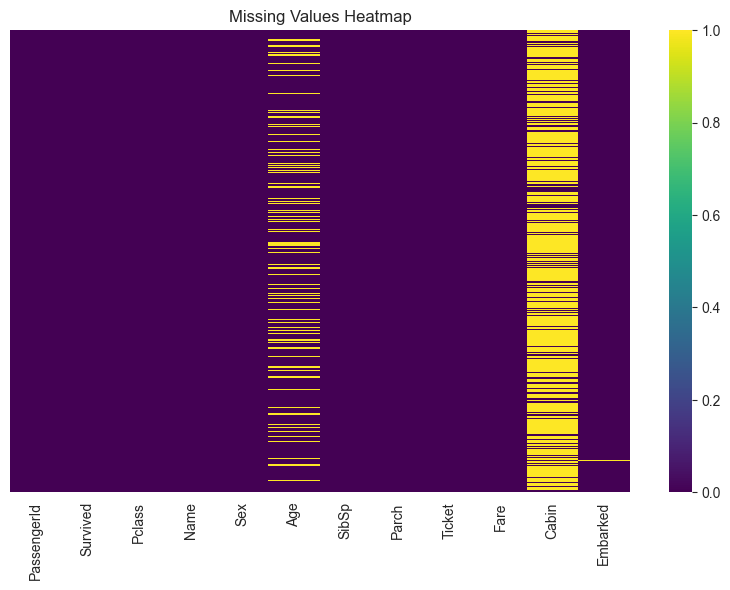

Missing Values Summary:
          Missing  Percentage
Cabin         687   77.104377
Age           177   19.865320
Embarked        2    0.224467


In [4]:
# Create heatmap to visualize where missing values are
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# Calculate percentage of missing values for each column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)
print("Missing Values Summary:")
print(missing_df)

In [5]:
# Create a copy to avoid modifying original data
train_clean = df.copy()

# Fill missing Embarked values with mode (most common value)
train_clean['Embarked'] = train_clean['Embarked'].fillna(train_clean['Embarked'].mode()[0])

# Create binary column: 1 if passenger had a cabin, 0 if not
train_clean['Has_Cabin'] = train_clean['Cabin'].notna().astype(int)

# Extract deck letter from cabin number (first character)
train_clean['Deck'] = train_clean['Cabin'].str[0]
# Replace missing deck values with 'U' (Unknown)
train_clean['Deck'] = train_clean['Deck'].fillna('U')

# Verify missing values are handled
print("Missing values after cleaning:")
print(train_clean.isnull().sum())

Missing values after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Has_Cabin        0
Deck             0
dtype: int64


In [6]:
# Extract title from passenger name (Mr, Mrs, Miss, etc.)
train_clean['Title'] = train_clean['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Group rare titles into single category
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Lady': 'Rare', 'Countess': 'Rare', 'Don': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare', 'Ms': 'Miss',
    'Mme': 'Mrs', 'Capt': 'Rare'
}
train_clean['Title'] = train_clean['Title'].map(title_map)
print("Title distribution:")
print(train_clean['Title'].value_counts())

# Fill missing Age values with median age for each title group
age_median_by_title = train_clean.groupby('Title')['Age'].transform('median')
train_clean['Age'] = train_clean['Age'].fillna(age_median_by_title)
# Fill any remaining missing ages with overall median
train_clean['Age'] = train_clean['Age'].fillna(train_clean['Age'].median())

print(f"Age missing values after imputation: {train_clean['Age'].isnull().sum()}")

Title distribution:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64
Age missing values after imputation: 0


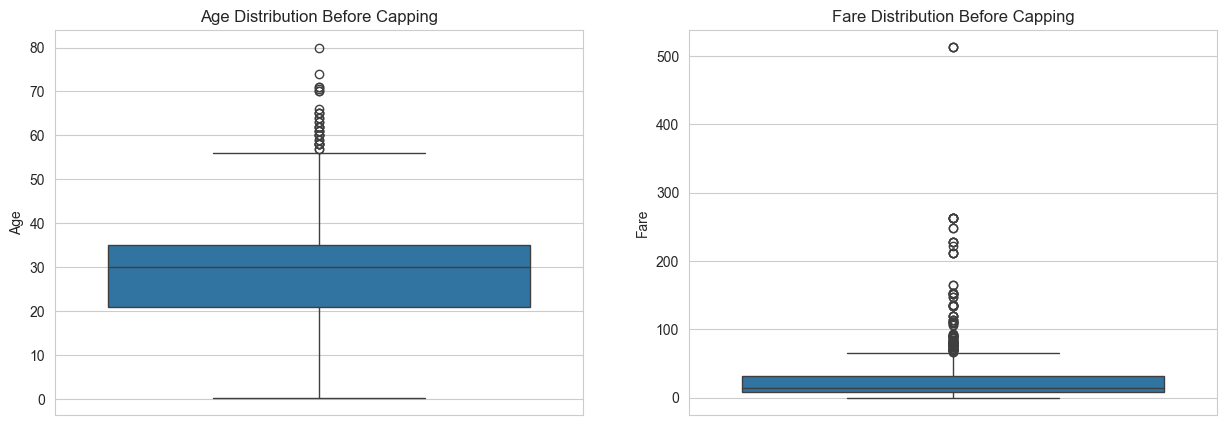

Fare 95th percentile: 112.08
Age cap at 3 standard deviations: 69.2


In [7]:
# Visualize outliers in Age and Fare
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=train_clean, y='Age', ax=axes[0])
axes[0].set_title('Age Distribution Before Capping')

sns.boxplot(data=train_clean, y='Fare', ax=axes[1])
axes[1].set_title('Fare Distribution Before Capping')
plt.show()

# Cap Fare at 95th percentile to reduce extreme values
fare_95 = train_clean['Fare'].quantile(0.95)
print(f"Fare 95th percentile: {fare_95:.2f}")
train_clean['Fare'] = np.where(train_clean['Fare'] > fare_95, fare_95, train_clean['Fare'])

# Cap Age at 3 standard deviations above mean
age_mean = train_clean['Age'].mean()
age_std = train_clean['Age'].std()
age_cap = age_mean + 3*age_std
print(f"Age cap at 3 standard deviations: {age_cap:.1f}")
train_clean['Age'] = np.where(train_clean['Age'] > age_cap, age_cap, train_clean['Age'])

In [8]:
# Calculate total family size (passenger + siblings/spouse + parents/children)
train_clean['FamilySize'] = train_clean['SibSp'] + train_clean['Parch'] + 1

# Create binary column: 1 if passenger is alone, 0 if with family
train_clean['IsAlone'] = (train_clean['FamilySize'] == 1).astype(int)

# Calculate fare per person to account for group tickets
train_clean['FarePerPerson'] = train_clean['Fare'] / train_clean['FamilySize']

# Preview new features
train_clean[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Fare', 'FarePerPerson']].head(10)

,SibSp,Parch,FamilySize,IsAlone,Fare,FarePerPerson
0,1,0,2,0,7.2500,3.62500
1,1,0,2,0,71.2833,35.64165
2,0,0,1,1,7.9250,7.92500
3,1,0,2,0,53.1000,26.55000
4,0,0,1,1,8.0500,8.05000
5,0,0,1,1,8.4583,8.45830
6,0,0,1,1,51.8625,51.86250
7,3,1,5,0,21.0750,4.21500
8,0,2,3,0,11.1333,3.71110
9,1,0,2,0,30.0708,15.03540


Age group distribution:
AgeGroup
Adult      530
Senior     196
Child       73
Teen        70
Elderly     22
Name: count, dtype: int64


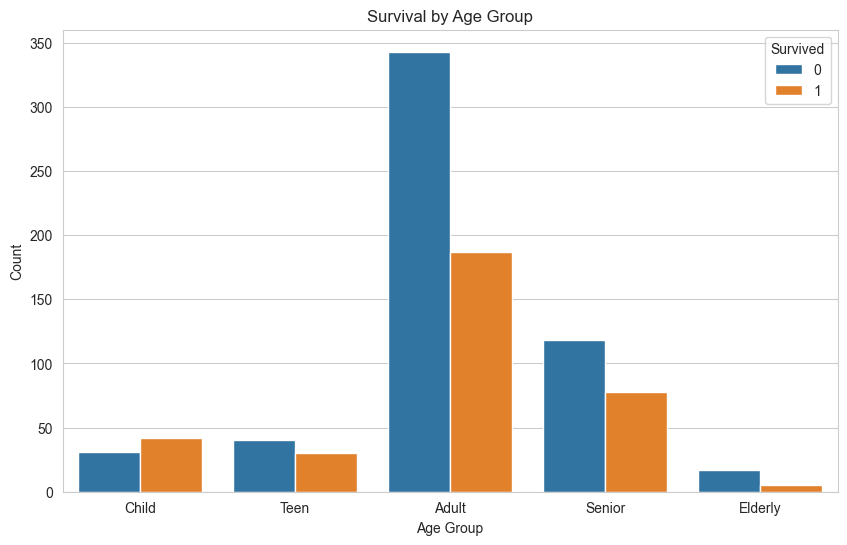

In [9]:
# Define age bins and labels
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior', 'Elderly']

# Create categorical age group column
train_clean['AgeGroup'] = pd.cut(train_clean['Age'], bins=bins, labels=labels)

print("Age group distribution:")
print(train_clean['AgeGroup'].value_counts())

# Plot survival rate by age group
plt.figure(figsize=(10, 6))
sns.countplot(data=train_clean, x='AgeGroup', hue='Survived')
plt.title('Survival by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

In [10]:
# Save target variable separately
target = train_clean['Survived']

# List of categorical columns to encode
categorical_features = ['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup']

# Create dummy variables for each category
encoded_dummies = pd.get_dummies(train_clean[categorical_features], drop_first=False)

# Remove original categorical columns and target from main dataframe
train_encoded = train_clean.drop(columns=categorical_features + ['Survived'])

# Add encoded dummy columns
train_encoded = pd.concat([train_encoded, encoded_dummies], axis=1)

# Add target variable back
train_encoded['Survived'] = target.values

print(f"Shape after encoding: {train_encoded.shape}")
print(f"Total columns: {len(train_encoded.columns)}")

Shape after encoding: (891, 38)
Total columns: 38


Fare skewness before: 1.72
Fare_log skewness after: 0.08


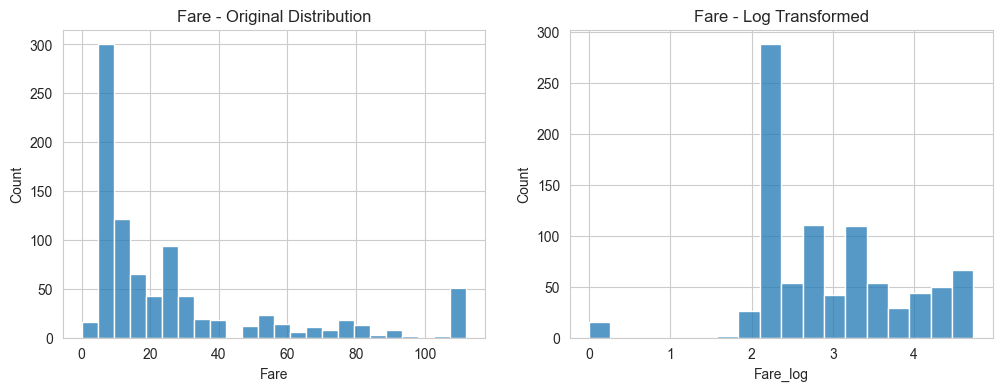

In [11]:
# Check skewness of Fare before transformation
print(f"Fare skewness before: {train_encoded['Fare'].skew():.2f}")

# Apply log transformation to reduce skew (adding 1 to avoid log of zero)
train_encoded['Fare_log'] = np.log1p(train_encoded['Fare'])
train_encoded['FarePerPerson_log'] = np.log1p(train_encoded['FarePerPerson'])

print(f"Fare_log skewness after: {train_encoded['Fare_log'].skew():.2f}")

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_encoded['Fare'], ax=axes[0])
axes[0].set_title('Fare - Original Distribution')
sns.histplot(train_encoded['Fare_log'], ax=axes[1])
axes[1].set_title('Fare - Log Transformed')
plt.show()

In [12]:
# Prepare feature matrix X (excluding identifier, target, and text columns)
X = train_encoded.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
y = train_encoded['Survived']

print(f"Features for modeling: {X.shape[1]}")

# Calculate correlation of each feature with survival
correlations = X.corrwith(y).abs().sort_values(ascending=False)

# Display top 15 features
print("Top 15 features by correlation with survival:")
print(correlations.head(15))

Features for modeling: 35
Top 15 features by correlation with survival:
Title_Mr             0.549199
Sex_male             0.543351
Sex_female           0.543351
Title_Mrs            0.341994
Pclass               0.338481
Title_Miss           0.335636
Fare_log             0.330314
Deck_U               0.316912
Has_Cabin            0.316912
Fare                 0.314682
FarePerPerson_log    0.296203
FarePerPerson        0.278955
IsAlone              0.203367
Deck_B               0.175095
Embarked_C           0.168240
dtype: float64


Top 15 most important features:
              Feature  Importance
1                 Age    0.144537
16           Title_Mr    0.096038
8       FarePerPerson    0.081686
34  FarePerPerson_log    0.081502
33           Fare_log    0.080360
10           Sex_male    0.078216
4                Fare    0.075508
9          Sex_female    0.060296
0              Pclass    0.039259
6          FamilySize    0.032696
15         Title_Miss    0.030023
17          Title_Mrs    0.028133
2               SibSp    0.019134
27             Deck_U    0.016103
5           Has_Cabin    0.015095


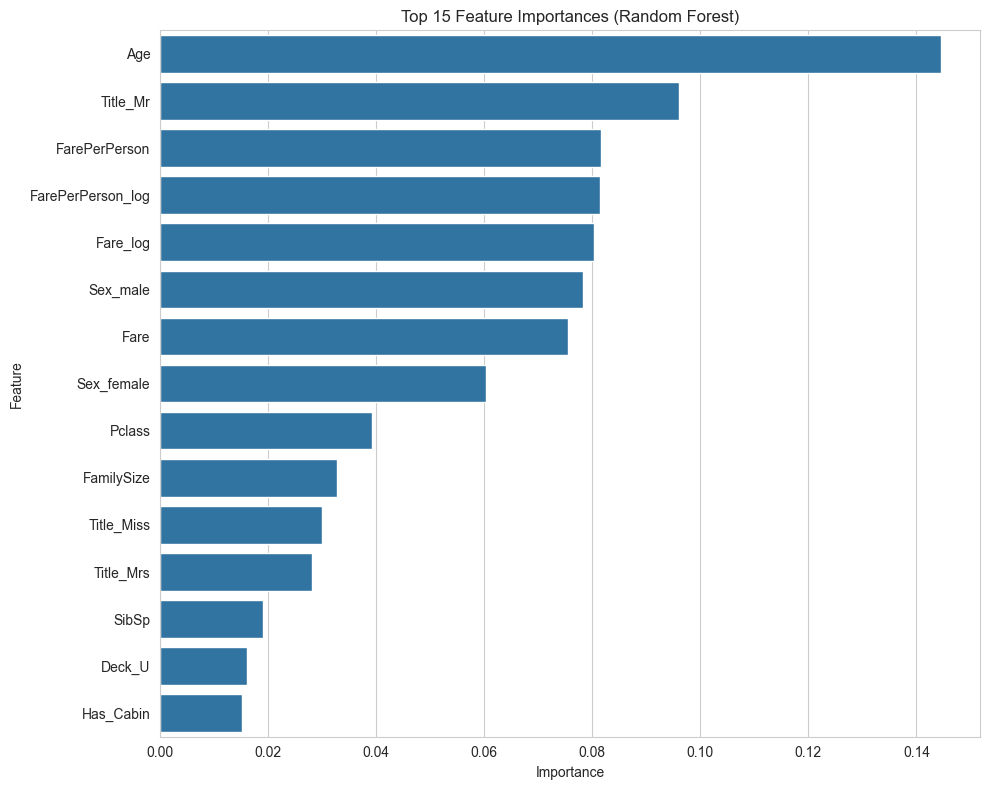

In [13]:
# Train random forest to determine feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Create dataframe of feature importances
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 most important features:")
print(importance_df.head(15))

# Plot feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [14]:
# Select top 10 features using RFE
rfe = RFE(estimator=RandomForestClassifier(n_estimators=50, random_state=42), n_features_to_select=10)
rfe.fit(X, y)

# Get list of selected features
selected_features = X.columns[rfe.support_].tolist()

print("Selected Features (Top 10):")
print("="*40)
for i, feature in enumerate(selected_features, 1):
    corr = X[feature].corr(y)
    print(f"{i}. {feature} (correlation: {corr:.3f})")

Selected Features (Top 10):
1. Pclass (correlation: -0.338)
2. Age (correlation: -0.080)
3. Fare (correlation: 0.315)
4. FamilySize (correlation: 0.017)
5. FarePerPerson (correlation: 0.279)
6. Sex_female (correlation: 0.543)
7. Sex_male (correlation: -0.543)
8. Title_Mr (correlation: -0.549)
9. Fare_log (correlation: 0.330)
10. FarePerPerson_log (correlation: 0.296)


In [15]:
# Save the cleaned dataset (before encoding)
train_clean.to_csv('data/train_cleaned.csv', index=False)
print("Saved: data/train_cleaned.csv")

# Save final dataset with selected features only
selected_cols = ['PassengerId', 'Survived'] + selected_features
train_final = train_encoded[selected_cols]
train_final.to_csv('data/train_processed.csv', index=False)
print("Saved: data/train_processed.csv")

print(f"Final dataset shape: {train_final.shape}")
print(f"Final features: {train_final.columns.tolist()}")

Saved: data/train_cleaned.csv
Saved: data/train_processed.csv
Final dataset shape: (891, 12)
Final features: ['PassengerId', 'Survived', 'Pclass', 'Age', 'Fare', 'FamilySize', 'FarePerPerson', 'Sex_female', 'Sex_male', 'Title_Mr', 'Fare_log', 'FarePerPerson_log']


In [17]:
print("="*60)
print("DATA CLEANING AND FEATURE ENGINEERING SUMMARY")
print("="*60)

print("\nMissing Value Handling:")
print("- Age (19% missing): Imputed with median age by passenger title")
print("- Embarked (0.2% missing): Filled with mode 'S'")
print("- Cabin (77% missing): Created Has_Cabin indicator and extracted Deck")

print("\nOutlier Handling:")
print("- Fare: Capped at 95th percentile")
print("- Age: Capped at 3 standard deviations")

print("\nFeature Engineering:")
print("- Title: Extracted from Name (Mr, Mrs, Miss, Master, Rare)")
print("- FamilySize = SibSp + Parch + 1")
print("- IsAlone = 1 if FamilySize == 1 else 0")
print("- FarePerPerson = Fare / FamilySize")
print("- AgeGroup: Child, Teen, Adult, Senior, Elderly")
print("- Deck: First letter of Cabin ('U' for unknown)")

print("\nTransformations Applied:")
print("- Log transform on Fare (reduced skewness)")
print("- One-hot encoding for categorical variables")

print("\nFinal Selected Features:")
for i, feat in enumerate(selected_features, 1):
    corr = X[feat].corr(y)
    print(f"  {i}. {feat}")



DATA CLEANING AND FEATURE ENGINEERING SUMMARY

Missing Value Handling:
- Age (19% missing): Imputed with median age by passenger title
- Embarked (0.2% missing): Filled with mode 'S'
- Cabin (77% missing): Created Has_Cabin indicator and extracted Deck

Outlier Handling:
- Fare: Capped at 95th percentile
- Age: Capped at 3 standard deviations

Feature Engineering:
- Title: Extracted from Name (Mr, Mrs, Miss, Master, Rare)
- FamilySize = SibSp + Parch + 1
- IsAlone = 1 if FamilySize == 1 else 0
- FarePerPerson = Fare / FamilySize
- AgeGroup: Child, Teen, Adult, Senior, Elderly
- Deck: First letter of Cabin ('U' for unknown)

Transformations Applied:
- Log transform on Fare (reduced skewness)
- One-hot encoding for categorical variables

Final Selected Features:
  1. Pclass
  2. Age
  3. Fare
  4. FamilySize
  5. FarePerPerson
  6. Sex_female
  7. Sex_male
  8. Title_Mr
  9. Fare_log
  10. FarePerPerson_log
